# РК1 по дисциплине Технологии машинного обучения
Гайнуллин А.М. ИУ5-62Б 
Вариант 3  
Задание: Для заданного набора данных проведите корреляционный анализ. В случае наличия пропусков в данных удалите строки или колонки, содержащие пропуски. Сделайте выводы о возможности построения моделей машинного обучения и о возможном вкладе признаков в модель.  
Дополнительное задание: для произвольной колонки данных построить гистограмму  
Датасет: https://www.kaggle.com/carlolepelaars/toy-dataset

In [7]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

In [8]:
#Загрузка данных
df = pd.read_csv('toy_dataset.csv')
df.head()

,Number,City,Gender,Age,Income,Illness
0,1,Dallas,Male,41,40367.0,No
1,2,Dallas,Male,54,45084.0,No
2,3,Dallas,Male,42,52483.0,No
3,4,Dallas,Male,40,40941.0,No
4,5,Dallas,Male,46,50289.0,No


In [9]:
#Анализ и удаление пропусков
print('Количество пропусков в каждом столбце:')
print(df.isnull().sum())

# Удалим строки с пропусками
df_clean = df.dropna()
print('\nРазмер после удаления пропусков:', df_clean.shape)

Количество пропусков в каждом столбце:
Number     0
City       0
Gender     0
Age        0
Income     0
Illness    0
dtype: int64

Размер после удаления пропусков: (150000, 6)


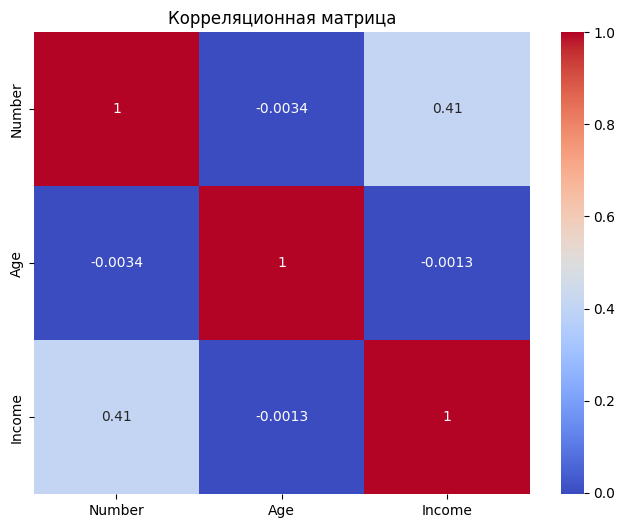

,Number,Age,Income
Number,1.000000,-0.003448,0.410460
Age,-0.003448,1.000000,-0.001318
Income,0.410460,-0.001318,1.000000


In [10]:
#Корреляционный анализ
# Выберем числовые признаки
numeric_cols = df_clean.select_dtypes(include=[np.number]).columns
corr_matrix = df_clean[numeric_cols].corr()
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title('Корреляционная матрица')
plt.show()

corr_matrix

**Выводы:**
- Признаки `Age` и `Income` имеют -0.0013 корреляцию.
- Признак `Number` служит только идентификатором и не вносит полезной информации.
- Для машинного обучения можно использовать признаки `Age`, `Income` и закодированный `Illness`.
- Необходимо закодировать категориальные признаки (например, `Gender`, `City`, `Illness`) перед обучением.

In [11]:
#Пример кодирования категориального признака
df_ml = df_clean.copy()
df_ml['Illness_encoded'] = df_ml['Illness'].map({'No': 0, 'Yes': 1})
df_ml.head()

,Number,City,Gender,Age,Income,Illness,Illness_encoded
0,1,Dallas,Male,41,40367.0,No,0
1,2,Dallas,Male,54,45084.0,No,0
2,3,Dallas,Male,42,52483.0,No,0
3,4,Dallas,Male,40,40941.0,No,0
4,5,Dallas,Male,46,50289.0,No,0


**Вывод о моделировании:**
- После подготовки данных (удаления пропусков и кодирования) можно применять модели, такие как линейная регрессия, решающие деревья и т.д.
- Наиболее вклад будут вносить `Income` и `Age`, а также закодированный `Illness`. Категориальные признаки `City` и `Gender` можно добавить через One-Hot Encoding.

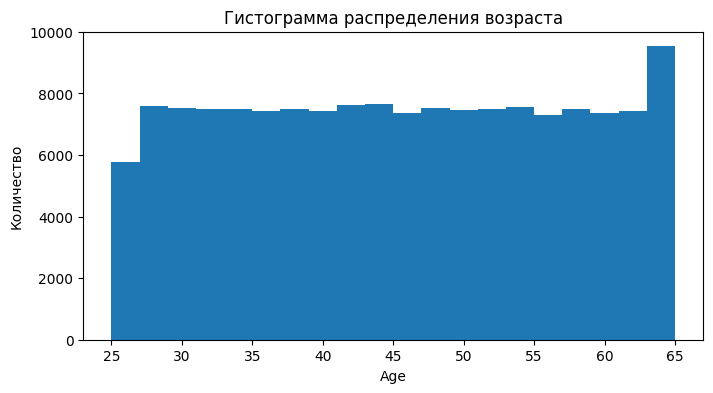

In [12]:
# Дополнительное задание: Гистограмма для столбца 'Age'
plt.figure(figsize=(8, 4))
plt.hist(df_clean['Age'], bins=20)
plt.xlabel('Age')
plt.ylabel('Количество')
plt.title('Гистограмма распределения возраста')
plt.show()